In [41]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
from pathlib import Path

In [3]:
import kagglehub
import shutil
dataset = "jangedoo/utkface-new"

cache_path = kagglehub.dataset_download(dataset)



# project_data = Path("/content/face_aging_app/data/raw/")
# project_data.mkdir(parents=True, exist_ok=True)

# shutil.copytree(cache_path, project_data, dirs_exist_ok=True)

print("Saved dataset to:", cache_path)

Using Colab cache for faster access to the 'utkface-new' dataset.
Saved dataset to: /kaggle/input/utkface-new


In [4]:
data_path = Path(cache_path, "utkface_aligned_cropped/UTKFace")

images = list(data_path.glob("*.jpg"))
print (len(images))



23708


In [5]:
import pandas as pd


records = []

for img_path in data_path.glob("*.jpg"):
    try:
        age, gender, race, _ = img_path.name.split("_", 3)
        
        records.append({
            "image_path": str(img_path),
            "age": int(age),
            "gender": int(gender),
            "race": int(race)
        })
        
    except:
        continue

df = pd.DataFrame(records)

print("Dataset loaded with shape:", df.shape)
df.head()



Dataset loaded with shape: (23705, 4)


,image_path,age,gender,race
0,/kaggle/input/utkface-new/utkface_aligned_crop...,26,0,2
1,/kaggle/input/utkface-new/utkface_aligned_crop...,22,1,1
2,/kaggle/input/utkface-new/utkface_aligned_crop...,21,1,3
3,/kaggle/input/utkface-new/utkface_aligned_crop...,28,0,0
4,/kaggle/input/utkface-new/utkface_aligned_crop...,17,1,4


In [6]:
def age_group(age):
    if age < 30:
        return "young"
    elif age < 55:
        return "middle"
    else:
        return "old"

df["age_group"] = df["age"].apply(age_group)

df.head()


#df.to_csv("/content/face_aging_app/utkface_metadata.csv", index=False)

,image_path,age,gender,race,age_group
0,/kaggle/input/utkface-new/utkface_aligned_crop...,26,0,2,young
1,/kaggle/input/utkface-new/utkface_aligned_crop...,22,1,1,young
2,/kaggle/input/utkface-new/utkface_aligned_crop...,21,1,3,young
3,/kaggle/input/utkface-new/utkface_aligned_crop...,28,0,0,young
4,/kaggle/input/utkface-new/utkface_aligned_crop...,17,1,4,young


Preprocessing


In [7]:
#df = pd.read_csv("/content/face_aging_app/utkface_metadata.csv")

# make sure paths are strings
df["image_path"] = df["image_path"].astype(str)


In [8]:
df = df[df["age"].between(10, 100)]


df = df.reset_index(drop=True)
print("Remaining samples:", len(df))

Remaining samples: 20622


In [9]:
#due to high cost of performing the training on whole dataset we will use a subset of it for training and testing

df = (
    df.groupby("age_group")
      .sample(n=1500, random_state=42)
      .reset_index(drop=True)
)

In [10]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["age_group"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["age_group"],
    random_state=42
)

# train_df.to_csv("/content/face_aging_app/train.csv", index=False)
# val_df.to_csv("/content/face_aging_app/val.csv", index=False)
# test_df.to_csv("/content/face_aging_app/test.csv", index=False)

In [11]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

class InstanceNormalization(tf.keras.layers.Layer):
    def __init__(self, epsilon=1e-5):
        super().__init__()
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(
            shape=(input_shape[-1],),
            initializer="ones",
            trainable=True,
        )
        self.beta = self.add_weight(
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True,
        )

    def call(self, x):
        mean, variance = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        x = (x - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * x + self.beta


Num GPUs Available: 1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# import pandas as pd

# train_df = pd.read_csv("/content/face_aging_app/train.csv")
# val_df = pd.read_csv("/content/face_aging_app/val.csv")
# test_df = pd.read_csv("/content/face_aging_app/test.csv")

In [12]:
import tensorflow as tf
from tensorflow.keras import mixed_precision


IMG_SIZE = 128
BATCH_SIZE = 2
AUTOTUNE = tf.data.AUTOTUNE
LEARNING_RATE = 1e-4
BETA_1 = 0.5

mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [13]:
#load the splits
young_df = train_df[train_df["age_group"] == "young"]
old_df = train_df[train_df["age_group"] == "old"]

In [14]:
sample_path = young_df["image_path"].iloc[0]
def load_test_image(path):

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), antialias=True)

    img = tf.cast(img, tf.float32) / 255.0
    img = (img * 2) - 1

    return img

sample_young = tf.expand_dims(load_test_image(sample_path), 0)

In [15]:
def load_image(path):

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE),antialias=True)

    #convert
    img = tf.cast(img, tf.float32) / 255.0

    #for better generalization, we can add some random flips
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    img = tf.image.random_brightness(img, 0.1)

    #normalize to [-1, 1]
    img = (img * 2) - 1

    return img

In [16]:
young_dataset = (
    tf.data.Dataset.from_tensor_slices(young_df["image_path"])
    .shuffle(2000)
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

old_dataset = (
    tf.data.Dataset.from_tensor_slices(old_df["image_path"])
    .shuffle(2000)
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)



In [17]:
class InstanceNormalization(tf.keras.layers.Layer):
    def __init__(self, epsilon=1e-5):
        super().__init__()
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(
            shape=(input_shape[-1],),
            initializer="ones",
            trainable=True,
        )
        self.beta = self.add_weight(
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True,
        )

    def call(self, x):
        mean, variance = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        x = (x - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * x + self.beta

In [18]:

from tensorflow.keras import layers

def downsample(filters, size, apply_instancenorm=True):

    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()
    result.add(
        layers.Conv2D(filters, size, strides=2, padding="same",
                      kernel_initializer=initializer, use_bias=False)
    )

    if apply_instancenorm:
        result.add(InstanceNormalization())

    result.add(layers.LeakyReLU())

    return result

def upsample(filters, size):

    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()
    result.add(
        layers.Conv2DTranspose(filters, size, strides=2,
                               padding="same",
                               kernel_initializer=initializer,
                               use_bias=False)
    )

    result.add(InstanceNormalization())
    result.add(layers.ReLU())

    return result

In [19]:
import tensorflow as tf
from tensorflow.keras import layers

class ReflectionPadding2D(layers.Layer):
    def __init__(self, padding=(1,1), **kwargs):
        self.padding = tuple(padding)
        super().__init__(**kwargs)

    def call(self, x):
        padding_width, padding_height = self.padding
        return tf.pad(
            x,
            [[0,0],
             [padding_height,padding_height],
             [padding_width,padding_width],
             [0,0]],
            mode="REFLECT"
        )

In [20]:
def resnet_block(x, filters, use_dropout=True):

    skip = x

    y = ReflectionPadding2D((1,1))(x)
    y = layers.Conv2D(filters, kernel_size=3)(y)
    y = InstanceNormalization()(y)
    y = layers.ReLU()(y)

    if use_dropout:
        y = layers.Dropout(0.5)(y)

    y = ReflectionPadding2D((1,1))(y)
    y = layers.Conv2D(filters, kernel_size=3)(y)
    y = InstanceNormalization()(y)

    out = layers.Add()([skip, y])

    return out

In [21]:


def build_generator():

    inputs = layers.Input(shape=[IMG_SIZE,IMG_SIZE,3])

    # initial conv
    x = layers.Conv2D(64, 7, padding="same")(inputs)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)

    # downsample
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)

    # RESNET BLOCKS
    for _ in range(6):
        x = resnet_block(x, 256)

    # upsample
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)

   # Output layer
    x = ReflectionPadding2D((3,3))(x)
    outputs = layers.Conv2D(
        3,
        kernel_size=7,
        activation="tanh",
        dtype="float32"

    )(x)

    return tf.keras.Model(inputs, outputs)

In [22]:
generator_g = build_generator()
generator_f = build_generator()

In [ ]:
def build_discriminator():

    initializer = tf.random_normal_initializer(0.,0.02)

    inp = layers.Input(shape=[IMG_SIZE,IMG_SIZE,3])

    x = downsample(64,4,False)(inp)
    x = downsample(128,4)(x)
    x = downsample(256,4)(x)

    x = layers.Conv2D(512,4,strides=1,padding="same",
                      kernel_initializer=initializer)(x)
    x = InstanceNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(1,4,strides=1,padding="same",
                      kernel_initializer=initializer)(x)

    return tf.keras.Model(inp,x)

In [24]:
discriminator_x = build_discriminator()
discriminator_y = build_discriminator()

In [25]:
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [26]:
def discriminator_loss(real, generated):

    real_loss = loss_obj(tf.ones_like(real), real)
    generated_loss = loss_obj(tf.zeros_like(generated), generated)

    total_disc_loss = real_loss + generated_loss

    return total_disc_loss * 0.5

In [27]:
def generator_loss(generated):

    return loss_obj(tf.ones_like(generated), generated)

In [28]:
LAMBDA_CYCLE = 10
LAMBDA_IDENTITY = 5
def cycle_loss(real_image, cycled_image):

    loss = tf.reduce_mean(tf.abs(real_image - cycled_image))

    return LAMBDA_CYCLE * loss
def identity_loss(real_image, same_image):

    loss = tf.reduce_mean(tf.abs(real_image - same_image))

    return LAMBDA_IDENTITY * loss

generator_g_optimizer = tf.keras.optimizers.Adam(LEARNING_RATE, beta_1=BETA_1)
generator_f_optimizer = tf.keras.optimizers.Adam(LEARNING_RATE, beta_1=BETA_1)

discriminator_x_optimizer = tf.keras.optimizers.Adam(LEARNING_RATE, beta_1=BETA_1)
discriminator_y_optimizer = tf.keras.optimizers.Adam(LEARNING_RATE, beta_1=BETA_1)

In [29]:
import random

class ImagePool:

    def __init__(self, pool_size=50):

        self.pool_size = pool_size
        self.images = []

    def query(self, image):

        if len(self.images) < self.pool_size:
            self.images.append(image)
            return image

        if random.random() > 0.5:

            idx = random.randint(0, self.pool_size - 1)
            tmp = self.images[idx]
            self.images[idx] = image

            return tmp

        else:
            return image
        

fake_x_pool = ImagePool()
fake_y_pool = ImagePool()

In [30]:
@tf.function
def train_step(real_x, real_y):

    with tf.GradientTape(persistent=True) as tape:

        fake_y = generator_g(real_x, training=True)
        cycled_x = generator_f(fake_y, training=True)

        fake_x = generator_f(real_y, training=True)
        cycled_y = generator_g(fake_x, training=True)

        same_x = generator_f(real_x, training=True)
        same_y = generator_g(real_y, training=True)

        disc_real_x = discriminator_x(real_x, training=True)
        disc_real_y = discriminator_y(real_y, training=True)


        fake_x = fake_x_pool.query(fake_x)
        fake_y = fake_y_pool.query(fake_y)

        disc_fake_x = discriminator_x(fake_x)
        disc_fake_y = discriminator_y(fake_y)

        gen_g_loss = generator_loss(disc_fake_y)
        gen_f_loss = generator_loss(disc_fake_x)

        total_cycle_loss = cycle_loss(real_x, cycled_x) + cycle_loss(real_y, cycled_y)

        total_gen_g_loss = gen_g_loss + total_cycle_loss + identity_loss(real_y, same_y)
        total_gen_f_loss = gen_f_loss + total_cycle_loss + identity_loss(real_x, same_x)

        disc_x_loss = discriminator_loss(disc_real_x, disc_fake_x)
        disc_y_loss = discriminator_loss(disc_real_y, disc_fake_y)

    generator_g_gradients = tape.gradient(
        total_gen_g_loss,
        generator_g.trainable_variables
    )

    generator_f_gradients = tape.gradient(
        total_gen_f_loss,
        generator_f.trainable_variables
    )

    discriminator_x_gradients = tape.gradient(
        disc_x_loss,
        discriminator_x.trainable_variables
    )

    discriminator_y_gradients = tape.gradient(
        disc_y_loss,
        discriminator_y.trainable_variables
    )

    generator_g_optimizer.apply_gradients(
        zip(generator_g_gradients, generator_g.trainable_variables)
    )

    generator_f_optimizer.apply_gradients(
        zip(generator_f_gradients, generator_f.trainable_variables)
    )

    discriminator_x_optimizer.apply_gradients(
        zip(discriminator_x_gradients, discriminator_x.trainable_variables)
    )

    discriminator_y_optimizer.apply_gradients(
        zip(discriminator_y_gradients, discriminator_y.trainable_variables)
    )

In [31]:
#generate previews

import matplotlib.pyplot as plt

def generate_images(model, test_input):

    prediction = model(test_input, training=False)

    plt.figure(figsize=(6,3))

    display_list = [test_input[0], prediction[0]]
    title = ['Input', 'Generated']

    for i in range(2):
        plt.subplot(1,2,i+1)
        plt.title(title[i])

        img = (display_list[i] * 0.5) + 0.5
        img = tf.clip_by_value(img, 0, 1)
        plt.imshow(img)

        plt.axis('off')

    plt.show()

In [38]:
epoch_var = tf.Variable(0)
checkpoint = tf.train.Checkpoint(
    generator_g=generator_g,
    generator_f=generator_f,
    discriminator_x=discriminator_x,
    discriminator_y=discriminator_y,
    generator_g_optimizer=generator_g_optimizer,
    generator_f_optimizer=generator_f_optimizer,
    discriminator_x_optimizer=discriminator_x_optimizer,
    discriminator_y_optimizer=discriminator_y_optimizer,
    epoch = epoch_var
)

In [39]:
checkpoint_manager = tf.train.CheckpointManager(
    checkpoint,
    "/content/drive/MyDrive/face_aging_app/checkpoints",
    max_to_keep=30
)

In [ ]:
# import shutil
# import os

# # Clear old checkpoints to avoid incompatible model loading
# if os.path.exists("/content/drive/MyDrive/face_aging_app/checkpoints"):
#     shutil.rmtree("/content/drive/MyDrive/face_aging_app/checkpoints")
#     print("Cleared old checkpoints directory")

In [34]:
import os

SAMPLE_DIR = "/content/drive/MyDrive/face_aging_app/samples"
os.makedirs(SAMPLE_DIR, exist_ok=True)

import matplotlib.pyplot as plt

def save_samples(generator, test_input, epoch):

    prediction = generator(test_input, training=False)

    plt.figure(figsize=(8,4))

    for i in range(min(4, test_input.shape[0])):

        # input
        plt.subplot(2,4,i+1)
        plt.imshow((test_input[i] + 1) / 2)
        plt.axis("off")

        # generated
        plt.subplot(2,4,i+5)
        plt.imshow((prediction[i] + 1) / 2)
        plt.axis("off")

    path = f"{SAMPLE_DIR}/epoch_{epoch:03d}.png"

    plt.savefig(path)
    plt.close()

    print("Saved:", path)

In [ ]:
sample = next(iter(young_dataset))
print(tf.reduce_min(sample), tf.reduce_max(sample))

Restored from 1 - /content/drive/MyDrive/face_aging_app/checkpoints/ckpt-23
Epoch completed: 1
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_001.png


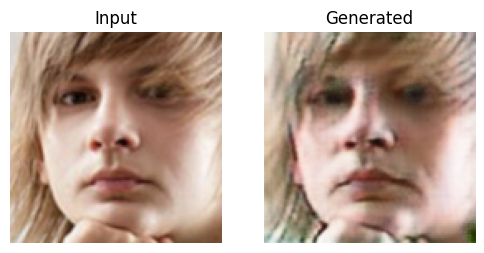

Epoch completed: 2
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_002.png


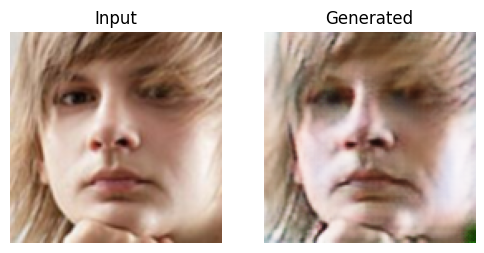

Epoch completed: 3
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_003.png


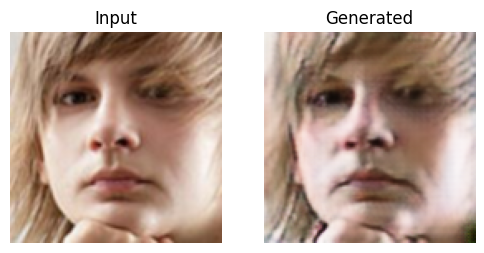

Epoch completed: 4
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_004.png


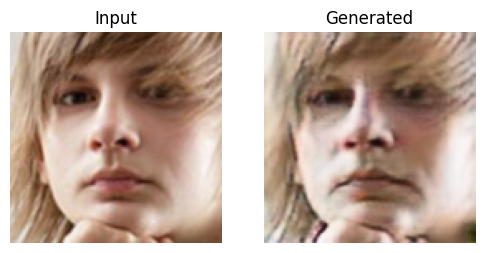

Epoch completed: 5
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_005.png


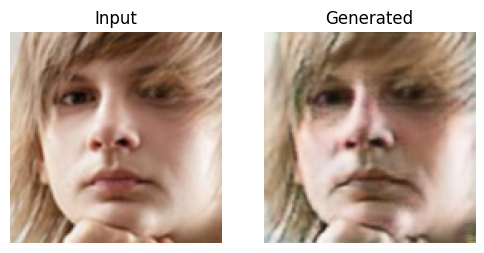

Epoch completed: 6
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_006.png


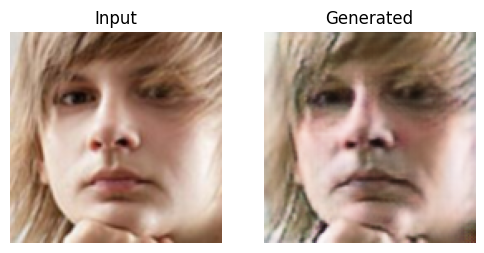

Epoch completed: 7
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_007.png


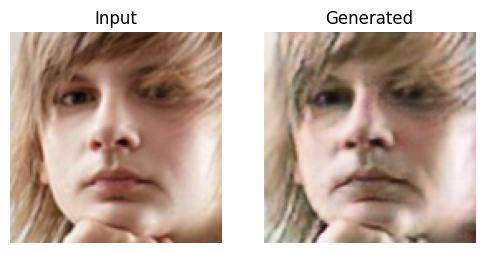

Epoch completed: 8
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_008.png


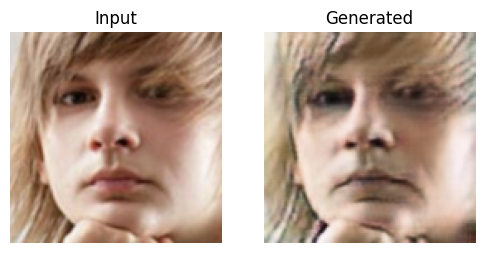

Epoch completed: 9
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_009.png


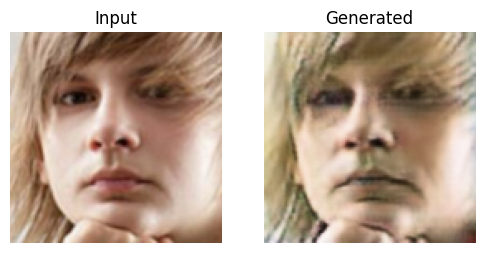

Epoch completed: 10
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_010.png


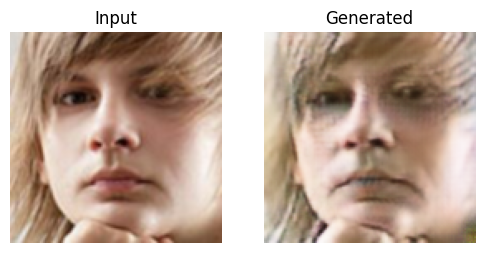

Epoch completed: 11
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_011.png


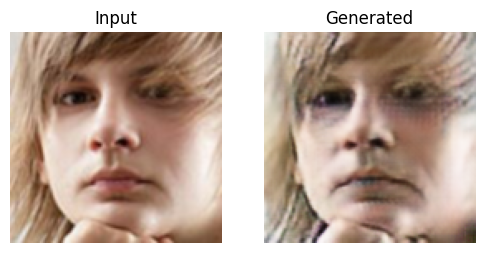

Epoch completed: 12
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_012.png


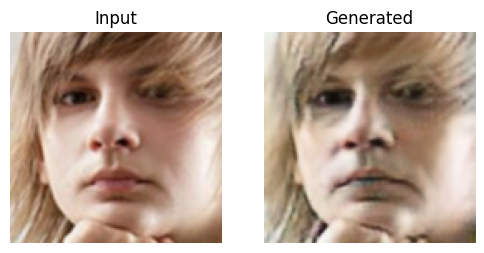

Epoch completed: 13
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_013.png


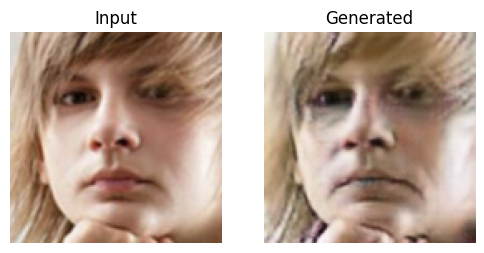

Epoch completed: 14
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_014.png


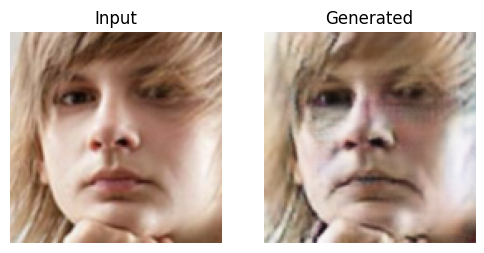

Epoch completed: 15
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_015.png


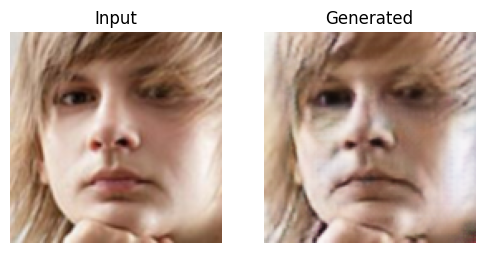

Epoch completed: 16
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_016.png


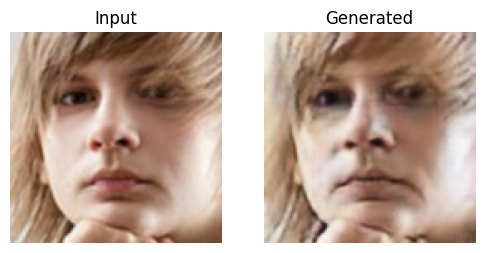

Epoch completed: 17
Saved: /content/drive/MyDrive/face_aging_app/samples/epoch_017.png


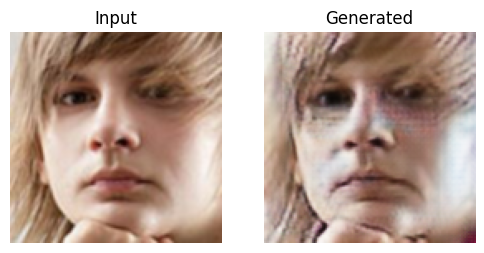

: 

: 

In [42]:
EPOCHS = 40

#for the previews
# sample_young = next(iter(young_dataset.take(1)))
# sample_young = sample_young[:1]

if checkpoint_manager.latest_checkpoint:
    checkpoint.restore(checkpoint_manager.latest_checkpoint)
    print("Restored from", int(epoch_var),"-", checkpoint_manager.latest_checkpoint)
else:
    print("Initializing from scratch.")


for epoch in range(int(epoch_var),EPOCHS):

    for image_x, image_y in tf.data.Dataset.zip((young_dataset, old_dataset)):
        train_step(image_x, image_y)

    print("Epoch completed:", epoch)
    save_samples(generator_g, sample_young, epoch)
    generate_images(generator_g, sample_young)
    epoch_var.assign_add(1)
    checkpoint_manager.save()
    
    if epoch % 5 == 0:
        generator_g.save(f"/content/drive/MyDrive/face_aging_app/models/generator_epoch_{epoch}.keras")